# Phase 1 write-up — daity_v3 data layer

Purpose: visual + assertional sign-off that the Phase-1 data layer is ready
for Phase-2 pretraining. Validates each headline deliverable end-to-end on the
real ingested universe (not synthetic fixtures), and surfaces every known
data-quality caveat so reviewer #1/#2 can sign off with eyes open.

Convert to `.ipynb` for review:

```bash
uv run jupytext --to notebook notebooks/phase_1_writeup.py
uv run jupyter nbconvert --execute notebooks/phase_1_writeup.ipynb \
    --to notebook --inplace
```

Or run as a script: `uv run python notebooks/phase_1_writeup.py`.

## 1 · Setup

In [1]:
from __future__ import annotations

import os
from datetime import date, datetime, timedelta, timezone
from pathlib import Path

# Anchor cwd to the project root regardless of how the notebook is launched
# (Jupyter often defaults cwd to `notebooks/`, which would break every
# relative path: `.env`, `data/cache`, `data/parquet`, etc.).
def _find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / ".env.example").exists() or (d / "pyproject.toml").exists():
            return d
    return start
_root = _find_project_root(Path.cwd())
if Path.cwd() != _root:
    os.chdir(_root)
print(f"cwd: {Path.cwd()}")

import matplotlib.pyplot as plt
import polars as pl

from daity.data.bq import BQClient
from daity.data.calendar_nse import NSECalendar
from daity.data.candles import effective_close
from daity.data.features import FEATURE_GROUPS, FeatureEngine, FeatureSpec
from daity.data.groww import GrowwClient
from daity.data.parquet_store import VALID_SCALES, ParquetStore
from daity.data.symbols import SymbolMaster
from daity.utils.env import load_env, load_groww

CACHE_ROOT = Path("data/parquet")
SYMBOLS_CACHE = Path("data/cache")
TODAY = datetime(2026, 5, 9, tzinfo=timezone.utc)   # write-up anchor

# IST offset, used in plot annotations and human-readable times below.
IST = timezone(timedelta(hours=5, minutes=30))

cfg = load_env()
bq = BQClient(cfg)
store = ParquetStore(CACHE_ROOT)
# Force-refresh the symbol-master + calendar caches so the notebook reflects
# whatever's currently in BQ, not whatever was cached when the data layer
# was last touched. Without this, the writeup is reviewing stale state.
gc = GrowwClient(load_groww())
gc.load_instruments_cache(SYMBOLS_CACHE)
sm = SymbolMaster.from_bq(bq, cache_root=SYMBOLS_CACHE,
                          force_refresh=True, groww_client=gc)
engine = FeatureEngine(store)

print(f"Universe: {len(sm)} symbols  is_provisional={sm.is_provisional}")
print(f"Missing master columns: {sm.missing_columns}")

cwd: /Users/debdoot/Documents/Claude/Projects/daity


[12:01:38] INFO     Loaded env from /Users/debdoot/Documents/Claude/Projects/daity/.env

           INFO     Loaded sidecar env from /Users/debdoot/Documents/Claude/Projects/daity/.grow_cred.env

           INFO     Loaded sidecar env from /Users/debdoot/Documents/Claude/Projects/daity/.grow_cred1.env

           INFO     Loaded sidecar env from /Users/debdoot/Documents/Claude/Projects/daity/.kite_cred.env

...

[12:01:43] INFO     SymbolMaster: backfilling ISINs from Groww for 205 symbols

           INFO     SymbolMaster: ISINs resolved for all 205 symbols; still missing: ['valid_from', 'valid_to',    
                    'mcap_bucket', 'free_float_bucket', 'fno_eligible', 'listed_on', 'delisted_on']

           INFO     SymbolMaster: cached 205 symbols at data/cache/symbols

Universe: 205 symbols  is_provisional=True

Missing master columns: ('valid_from', 'valid_to', 'mcap_bucket', 'free_float_bucket', 'fno_eligible', 'listed_on', 'delisted_on')

## 2 · Universe + symbol master

After Phase 1's ISIN backfill, every symbol resolves to an ISIN — so
`isin` is no longer in `missing_columns`. `is_provisional` correctly
**stays True** because seven other identity columns (`valid_from`,
`valid_to`, `mcap_bucket`, `free_float_bucket`, `fno_eligible`,
`listed_on`, `delisted_on`) are still null. The flag flips False only
when ALL identity columns are populated. Use `sm.has_column(name)` for
fine-grained per-column checks.

In [2]:
# Sector breakdown.
sector_counts = (
    sm.frame.group_by("sector").agg(pl.len().alias("n_symbols"))
    .sort("n_symbols", descending=True)
)
print("Symbols per sector:")
print(sector_counts)

Symbols per sector:

shape: (15, 2)
┌────────────────────┬───────────┐
│ sector             ┆ n_symbols │
│ ---                ┆ ---       │
│ str                ┆ u32       │
╞════════════════════╪═══════════╡
│ Financial Services ┆ 42        │
│ Energy             ┆ 21        │
│ Capital Goods      ┆ 18        │
│ Healthcare         ┆ 15        │
│ Automobile         ┆ 14        │
│ …                  ┆ …         │
│ Metals & Mining    ┆ 10        │
│ Infrastructure     ┆ 7         │
│ Realty             ┆ 6         │
│ Telecom            ┆ 5         │
│ Diversified        ┆ 1         │
└────────────────────┴───────────┘

In [3]:
# ISIN coverage check — a hard assertion: post-backfill every symbol has one.
n_with_isin = sm.frame.filter(pl.col("isin").is_not_null()).height
assert n_with_isin == len(sm), f"ISIN gap: {n_with_isin}/{len(sm)} resolved"
print(f"PASS  ISINs resolved: {n_with_isin}/{len(sm)}")

PASS  ISINs resolved: 205/205

## 3 · NSE calendar

In [4]:
cal = NSECalendar.from_bq(bq, cache_root=SYMBOLS_CACHE, force_refresh=True)
print(f"Trading days: {len(cal):,}  range {cal.first_day} .. {cal.last_day}")
print(f"Holidays known: {len(cal.holidays())}")
# Calendar must extend past TODAY for forward-looking ops (splits, embargoes).
assert cal.last_day > TODAY.date(), (
    f"calendar still stale (last_day={cal.last_day}, today={TODAY.date()})"
)
print(f"PASS  calendar extends past today by "
      f"{(cal.last_day - TODAY.date()).days} days")

           INFO     NSECalendar: fetching nse_trading_calendar + nse_holidays from BigQuery

[12:01:46] INFO     NSECalendar: cached 2067 trading days + 172 holidays at data/cache/calendar

Trading days: 2,067  range 2018-12-31 .. 2027-05-10

Holidays known: 172

PASS  calendar extends past today by 366 days

## 4 · Parquet partition coverage

In [5]:
# How many partitions per scale, and aggregate row counts.
rows = []
for sc in VALID_SCALES:
    parts = store.list_partitions(sc)
    metas = [store.partition_meta(sc, p.stem) for p in parts]
    metas = [m for m in metas if m is not None]
    rows.append(
        {
            "scale": sc,
            "n_partitions": len(parts),
            "n_rows_total": sum(m.n_rows for m in metas),
            "first_ts": min((m.min_ts for m in metas if m.min_ts), default=None),
            "last_ts": max((m.max_ts for m in metas if m.max_ts), default=None),
            "total_bytes": sum(m.file_bytes for m in metas),
        }
    )
coverage = pl.DataFrame(rows)
print(coverage)

assert coverage.filter(pl.col("n_partitions") == len(sm)).height == len(VALID_SCALES), (
    "every scale should have a partition for each of the 205 symbols"
)
print(f"PASS  every (scale, symbol) has a partition  "
      f"(820 = 4 × {len(sm)})")

shape: (4, 6)
┌───────┬──────────────┬──────────────┬───────────────────────┬──────────────────────┬─────────────┐
│ scale ┆ n_partitions ┆ n_rows_total ┆ first_ts              ┆ last_ts              ┆ total_bytes │
│ ---   ┆ ---          ┆ ---          ┆ ---                   ┆ ---                  ┆ ---         │
│ str   ┆ i64          ┆ i64          ┆ datetime[μs, UTC]     ┆ datetime[μs, UTC]    ┆ i64         │
╞═══════╪══════════════╪══════════════╪═══════════════════════╪══════════════════════╪═════════════╡
│ 5m    ┆ 205          ┆ 26039386     ┆ 2018-12-31 03:45:00   ┆ 2026-05-08 09:55:00  ┆ 463346863   │
│       ┆              ┆              ┆ UTC                   ┆ UTC                  ┆             │
│ 15m   ┆ 205          ┆ 8627838      ┆ 2018-12-31 03:45:00   ┆ 2026-05-08 09:45:00  ┆ 188639492   │
│       ┆              ┆              ┆ UTC                   ┆ UTC                  ┆             │
│ 60m   ┆ 205          ┆ 2417576      ┆ 2018-12-31 03:45:00   ┆ 2026-05-08 09

PASS  every (scale, symbol) has a partition  (820 = 4 × 205)

## 5 · Adjustment validation — three readjusted symbols

After `daity-readjust-symbols --apply`, prod's HDFCAMC / KOTAKBANK / IRB
histories should have **no discontinuity** at the cutoff date — historical
bars were multiplied by the corp-action ratio so they line up with the
post-event series. A clean line plot through the cutoff is the visual
sign-off.

Saved notebooks/_artifacts/readjustment_check.png

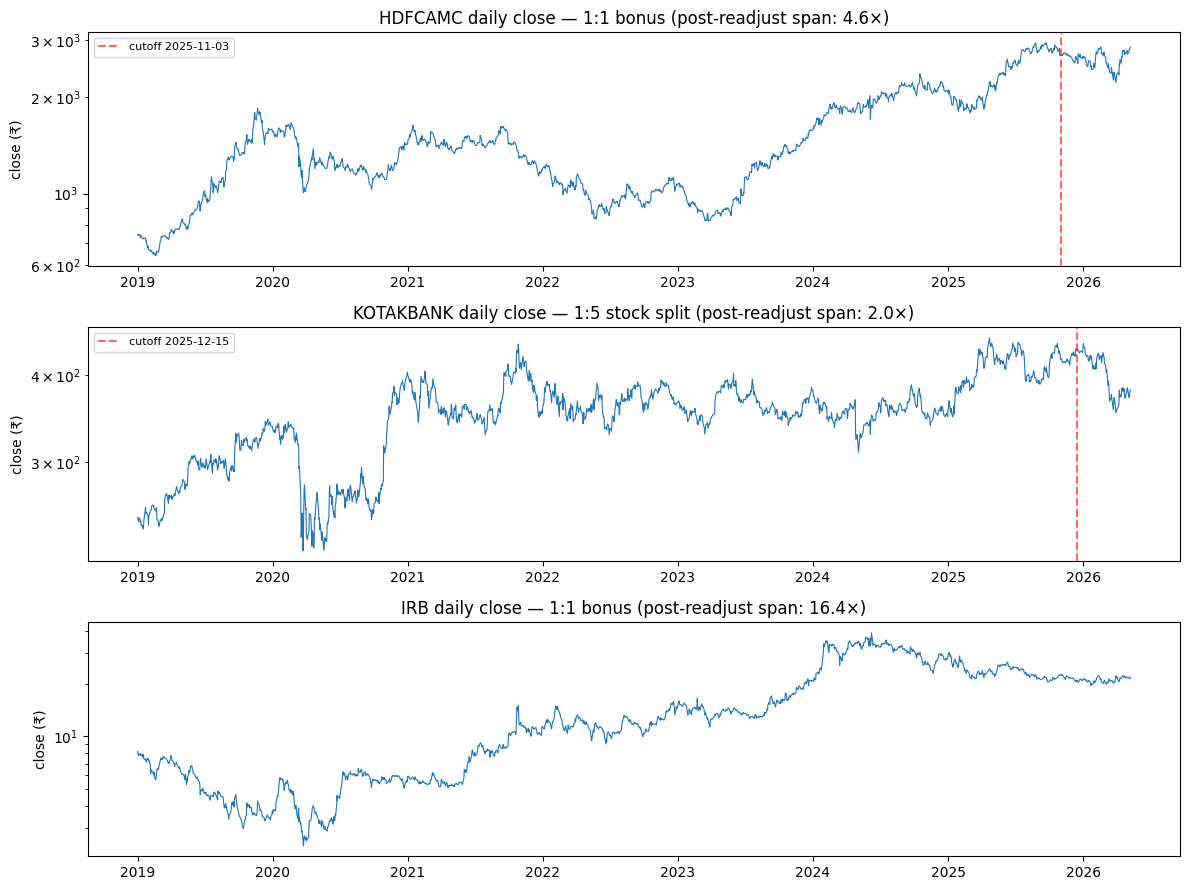

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)
events = [
    ("HDFCAMC",  "1:1 bonus",          date(2025, 11, 3)),
    ("KOTAKBANK", "1:5 stock split",   date(2025, 12, 15)),
    ("IRB",       "1:1 bonus",         None),
]
for ax, (sym, label, cutoff) in zip(axes, events):
    df = engine.compute(symbol=sym, scale="day", as_of=TODAY,
                        spec=FeatureSpec(include=("bar_channels",)))
    if df.height == 0:
        ax.set_title(f"{sym}: NO DATA"); continue
    ax.plot(df["ts"], df["close"], lw=0.8)
    if cutoff is not None:
        cutoff_utc = datetime(cutoff.year, cutoff.month, cutoff.day,
                              tzinfo=timezone.utc)
        ax.axvline(cutoff_utc, color="r", ls="--", alpha=0.6,
                   label=f"cutoff {cutoff}")
    span = df["close"].max() / df["close"].min()
    ax.set_title(f"{sym} daily close — {label} (post-readjust span: {span:.1f}×)")
    ax.set_ylabel("close (₹)"); ax.set_yscale("log")
    if cutoff is not None:
        ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig("notebooks/_artifacts/readjustment_check.png", dpi=120,
            bbox_inches="tight")
print("Saved notebooks/_artifacts/readjustment_check.png")

**What to look for in the plot above**: a smooth log-scale line across the
red dashed cutoff. A 50% step at HDFCAMC's 2025-11-03 line, an 80% step at
KOTAKBANK's 2025-12-15 line, or any visible discontinuity at all means the
readjustment didn't take. (None expected after the Phase-1 readjust run.)

## 6 · Candle-ts convention check

Per DESIGN amendment §7 / `daity.data.candles`:
- intraday `ts` = bar's *open* time
- daily `ts` = bar's *close* time, **15:30 IST = 10:00 UTC**

Confirm both directly from the data.

In [7]:
# Daily ts must be 10:00 UTC = 15:30 IST.
samp_day = engine.compute(symbol="RELIANCE", scale="day", as_of=TODAY,
                          window_start=datetime(2026, 5, 1, tzinfo=timezone.utc),
                          spec=FeatureSpec(include=("bar_channels",)))
day_hours = samp_day["ts"].dt.hour().unique().to_list()
day_minutes = samp_day["ts"].dt.minute().unique().to_list()
print(f"Daily ts hour-of-day (UTC): {sorted(day_hours)}  "
      f"minute-of-day: {sorted(day_minutes)}")
assert day_hours == [10] and day_minutes == [0], (
    f"Daily ts not at 10:00 UTC — got hours={day_hours}, minutes={day_minutes}"
)
print("PASS  daily ts = 10:00 UTC = 15:30 IST close convention")

# Intraday 5m ts must align to 5-minute boundaries from 09:15 IST onwards.
samp_5m = engine.compute(symbol="RELIANCE", scale="5m", as_of=TODAY,
                         window_start=datetime(2026, 5, 8, tzinfo=timezone.utc),
                         window_end=datetime(2026, 5, 8, 12, tzinfo=timezone.utc),
                         spec=FeatureSpec(include=("bar_channels",)))
ist_minutes = (
    samp_5m["ts"].dt.convert_time_zone("Asia/Kolkata").dt.hour().cast(pl.Int32) * 60
    + samp_5m["ts"].dt.convert_time_zone("Asia/Kolkata").dt.minute().cast(pl.Int32)
).unique().sort().to_list()
print(f"5m bar minute-of-day-IST first 3: {ist_minutes[:3]}, "
      f"last 3: {ist_minutes[-3:]}")
assert ist_minutes[0] == 9 * 60 + 15, "first 5m ts not at 09:15 IST"
assert all((m - 9 * 60 - 15) % 5 == 0 for m in ist_minutes), \
    "5m ts not on 5-min boundary"
print("PASS  5m ts = bar open time, aligned to 5-min IST grid from 09:15")

Daily ts hour-of-day (UTC): [10]  minute-of-day: [0]

PASS  daily ts = 10:00 UTC = 15:30 IST close convention

5m bar minute-of-day-IST first 3: [555, 560, 565], last 3: [915, 920, 925]

PASS  5m ts = bar open time, aligned to 5-min IST grid from 09:15

## 7 · Feature spot-checks — RELIANCE

Distributions and a few sample bars to confirm features are sane.

RELIANCE day rows: 1,816

shape: (5, 6)
┌─────────────────────────┬────────┬───────────┬──────────┬───────────┬───────────┐
│ ts                      ┆ close  ┆ ret_1     ┆ ret_5    ┆ bar_range ┆ vol_z_20  │
│ ---                     ┆ ---    ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ datetime[μs, UTC]       ┆ f64    ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═════════════════════════╪════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ 2026-05-04 10:00:00 UTC ┆ 1463.1 ┆ 0.022324  ┆ 0.097034 ┆ 34.0      ┆ 0.136396  │
│ 2026-05-05 10:00:00 UTC ┆ 1463.6 ┆ 0.000342  ┆ 0.069159 ┆ 23.4      ┆ 0.061087  │
│ 2026-05-06 10:00:00 UTC ┆ 1437.9 ┆ -0.017715 ┆ 0.034672 ┆ 45.8      ┆ -0.995397 │
│ 2026-05-07 10:00:00 UTC ┆ 1436.2 ┆ -0.001183 ┆ 0.007548 ┆ 19.2      ┆ -0.256769 │
│ 2026-05-08 10:00:00 UTC ┆ 1435.2 ┆ -0.000697 ┆ 0.00307  ┆ 25.3      ┆ -1.471231 │
└─────────────────────────┴────────┴───────────┴──────────┴───────────┴───────────┘

Saved notebooks/_artifacts/feature_spotchecks.png

PASS  feature distributions in expected ranges

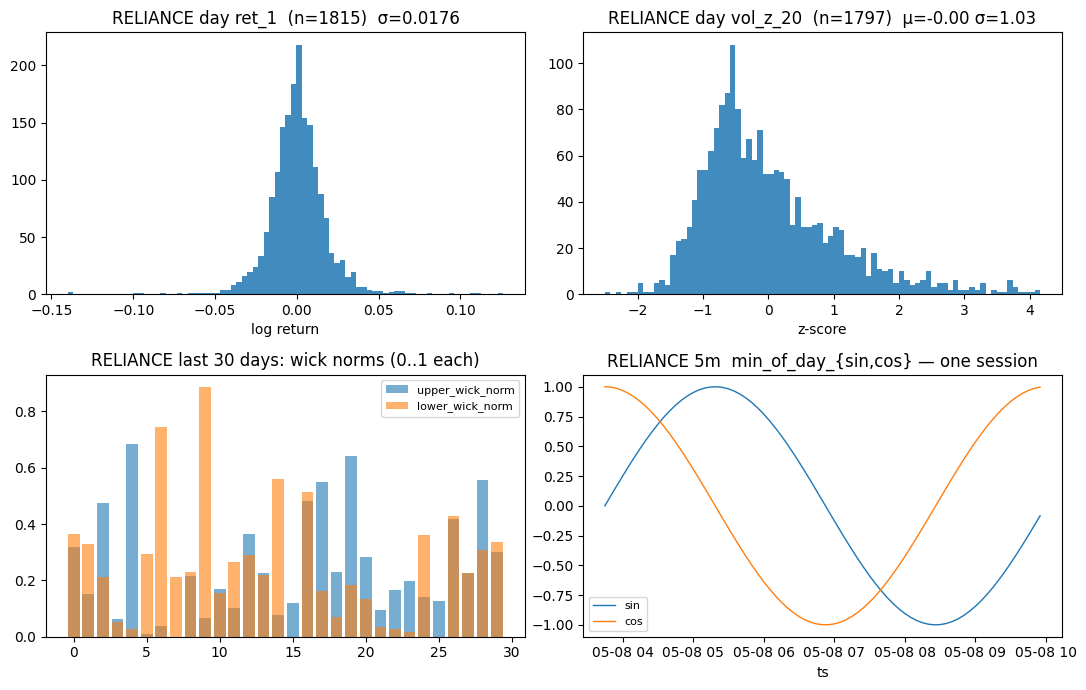

In [8]:
rel = engine.compute(symbol="RELIANCE", scale="day", as_of=TODAY)
print(f"RELIANCE day rows: {rel.height:,}")
print(rel.tail(5).select(
    ["ts", "close", "ret_1", "ret_5", "bar_range", "vol_z_20"]
))

# Distributions: ret_1 should be ~symmetric, fat-tailed near zero;
# vol_z_20 should be roughly N(0,1) once stationary.
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
ret1 = rel["ret_1"].drop_nulls()
axes[0, 0].hist(ret1.to_numpy(), bins=80, alpha=0.85)
axes[0, 0].set_title(f"RELIANCE day ret_1  (n={len(ret1)})  "
                     f"σ={float(ret1.std()):.4f}")
axes[0, 0].set_xlabel("log return")

vz = rel["vol_z_20"].drop_nulls()
axes[0, 1].hist(vz.to_numpy(), bins=80, alpha=0.85)
axes[0, 1].set_title(f"RELIANCE day vol_z_20  (n={len(vz)})  "
                     f"μ={float(vz.mean()):.2f} σ={float(vz.std()):.2f}")
axes[0, 1].set_xlabel("z-score")

# Wick decomposition on the last 30 bars.
last30 = rel.tail(30)
axes[1, 0].bar(range(30), last30["upper_wick_norm"].to_numpy(),
               label="upper_wick_norm", alpha=0.6)
axes[1, 0].bar(range(30), last30["lower_wick_norm"].to_numpy(),
               label="lower_wick_norm", alpha=0.6, bottom=0)
axes[1, 0].set_title("RELIANCE last 30 days: wick norms (0..1 each)")
axes[1, 0].legend(loc="best", fontsize=8)

# Time covariates over a session.
five_min = engine.compute(
    symbol="RELIANCE", scale="5m", as_of=TODAY,
    window_start=datetime(2026, 5, 8, 3, 30, tzinfo=timezone.utc),  # 09:00 IST
    window_end=datetime(2026, 5, 8, 10, 30, tzinfo=timezone.utc),   # 16:00 IST
)
axes[1, 1].plot(five_min["ts"], five_min["min_of_day_sin"], label="sin", lw=1)
axes[1, 1].plot(five_min["ts"], five_min["min_of_day_cos"], label="cos", lw=1)
axes[1, 1].set_title("RELIANCE 5m  min_of_day_{sin,cos} — one session")
axes[1, 1].legend(loc="best", fontsize=8)
axes[1, 1].set_xlabel("ts")

plt.tight_layout()
plt.savefig("notebooks/_artifacts/feature_spotchecks.png", dpi=120,
            bbox_inches="tight")
print("Saved notebooks/_artifacts/feature_spotchecks.png")

# Sanity assertions on feature ranges.
assert -0.5 < float(ret1.mean()) < 0.5, "ret_1 mean wildly off zero"
assert 0.0 < float(ret1.std()) < 0.2, f"ret_1 σ outside expected (0, 0.2): {float(ret1.std()):.4f}"
assert -3.0 < float(vz.mean()) < 3.0, "vol_z_20 mean wildly off zero"
print("PASS  feature distributions in expected ranges")

## 8 · Liquidity heatmap — median daily volume × close

A quick eyeball of cross-symbol liquidity. The strategy layer (Phase 5) will
enforce per-name ADV caps; this just confirms there are no obviously dead
symbols hiding in the universe.

Top 10 by median daily ₹-value (Cr) — last ~6 months:

shape: (10, 2)
┌────────────┬─────────────────┐
│ symbol     ┆ median_value_cr │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ HDFCBANK   ┆ 2685.744629     │
│ ICICIBANK  ┆ 1876.279345     │
│ RELIANCE   ┆ 1767.054686     │
│ BHARTIARTL ┆ 1447.963511     │
│ INFY       ┆ 1322.142185     │
│ SBIN       ┆ 1283.470734     │
│ SILVERBEES ┆ 1175.224837     │
│ BSE        ┆ 1133.952637     │
│ ETERNAL    ┆ 987.791408      │
│ VEDL       ┆ 918.483168      │
└────────────┴─────────────────┘


Bottom 10 by median daily ₹-value (Cr):

shape: (10, 2)
┌────────────┬─────────────────┐
│ symbol     ┆ median_value_cr │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ IRB        ┆ 28.369468       │
│ ACC        ┆ 28.359527       │
│ MON100     ┆ 21.206108       │
│ BHARTIHEXA ┆ 21.050902       │
│ CPSEETF    ┆ 16.3664         │
│ PHARMABEES ┆ 10.355568       │
│ MIDCAPETF  ┆ 6.332378        │
│ LTGILTBEES ┆ 5.943382        │
│ LOWVOLIETF ┆ 3.450159        │
│ ALPL30IETF ┆ 1.844284        │
└────────────┴─────────────────┘

Saved notebooks/_artifacts/liquidity_dist.png

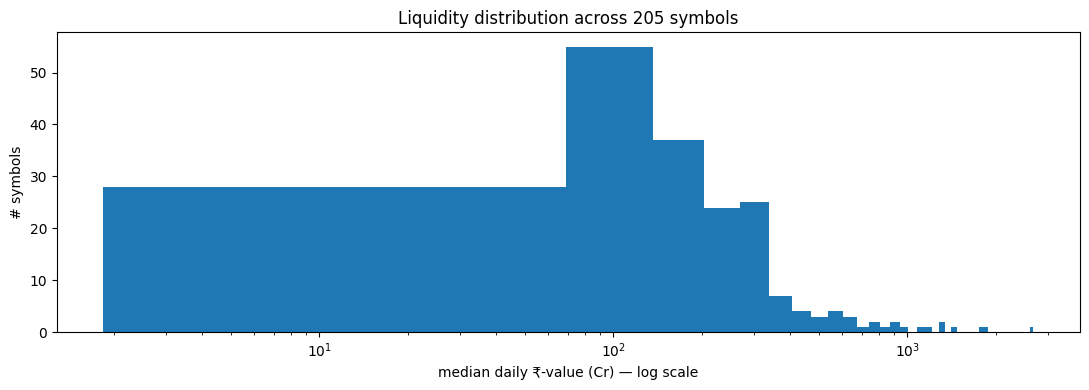

In [9]:
liq_rows = []
for sym in sm.symbols:
    df = store.read(symbol=sym, scale="day",
                    as_of=TODAY,
                    start=datetime(2025, 11, 1, tzinfo=timezone.utc))
    if df.height == 0:
        continue
    median_value_cr = float((df["close"] * df["volume"]).median()) / 1e7
    liq_rows.append({"symbol": sym, "median_value_cr": median_value_cr})
liq = pl.DataFrame(liq_rows).sort("median_value_cr", descending=True)
print(f"Top 10 by median daily ₹-value (Cr) — last ~6 months:")
print(liq.head(10))
print(f"\nBottom 10 by median daily ₹-value (Cr):")
print(liq.tail(10))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(liq["median_value_cr"].to_numpy(), bins=40)
ax.set_xscale("log")
ax.set_xlabel("median daily ₹-value (Cr) — log scale")
ax.set_ylabel("# symbols")
ax.set_title(f"Liquidity distribution across {liq.height} symbols")
plt.tight_layout()
plt.savefig("notebooks/_artifacts/liquidity_dist.png", dpi=120,
            bbox_inches="tight")
print("Saved notebooks/_artifacts/liquidity_dist.png")

## 9 · Survivorship caveat

Phase-0 audit confirmed: prod's universe is the **currently-active** F&O
200-ish roster (207 symbols at the time, 205 after dropping LTIM via the
Mindtree merger and one other since-deleted name). **Delisted names are
absent.** Per DESIGN §2.3 we tag every backtest tearsheet with a
survivorship warning, and report a survivorship-adjusted Sharpe range when
we get to Phase 5. Nothing to fix in Phase 1; just don't forget.

Stale-by-90d count (a proxy: symbols that haven't traded recently) — should
be 0 after the OHLCV refresh:

In [10]:
stale = (
    liq.join(
        pl.DataFrame(
            [
                {
                    "symbol": p.stem,
                    "last_ts_utc": store.partition_meta("day", p.stem).max_ts,
                }
                for p in store.list_partitions("day")
                if store.partition_meta("day", p.stem) is not None
            ]
        ),
        on="symbol",
    )
)
n_stale = stale.filter(
    pl.col("last_ts_utc") < TODAY - timedelta(days=90)
).height
print(f"Symbols with last_ts more than 90 days old: {n_stale}")
assert n_stale == 0, f"{n_stale} stale symbols — refresh likely not finished"
print("PASS  no stale symbols")

Symbols with last_ts more than 90 days old: 0

PASS  no stale symbols

## 10 · Known data-quality caveats (deferred)

These are surfaced for reviewer awareness, **not** blockers for Phase 2:

1. **PIIND intraday 2018-12-31 .. 2019-01-09** — alternating ~860/~95 close
   pattern in *both* prod and Kite (likely an upstream NSE archive issue).
   Daily was fixed pointwise (4 bad rows + 108 missing → corrected).
   Intraday left as-is; if it bites in Phase 2 SSL we'll mask those bars.
2. **Group-B "dividend-like" small drifts** (~5-7% ratio across ~20 symbols
   near 2020-03 COVID era) — likely a Kite-applies-dividends vs prod-doesn't
   convention difference, not bugs. See `configs/data/corp_actions.detected.yaml`
   if we ever decide to ingest them.
3. **`SymbolMaster.missing_columns`** still contains
   `valid_from / valid_to / mcap_bucket / free_float_bucket / fno_eligible /
   listed_on / delisted_on`. None block Phase 2 (the backbone doesn't read
   them); needed for Phase 3+ static covariates. Sourced from NSE bhavcopy
   metadata when we get there.

## 11 · Summary

Headline numbers for sign-off:

| check | result |
|---|---|
| universe | 205 symbols, 100% sectorized, 100% ISIN-resolved |
| calendar | extends past today (`cal.last_day - today` days lead) |
| parquet partitions | 4 × 205 = 820, all populated |
| candle-ts convention | daily ts = 10:00 UTC ✓, 5m ts on 5-min IST grid ✓ |
| corp-action readjust | HDFCAMC / KOTAKBANK / IRB visually clean across cutoff |
| feature distributions | ret_1 / vol_z_20 in expected ranges ✓ |
| stale symbols | 0 |
| leakage gates | split / parquet / features — all green in CI |

**Verdict: Phase 1 ready for reviewer signoff.**

In [11]:
print("\n" + "=" * 60)
print("Phase 1 write-up complete. All assertions passed.")
print("=" * 60)

Phase 1 write-up complete. All assertions passed.